# The agent-environment interaction

In this exercise, you will implement the interaction of a reinforecment learning agent with its environment. We will use the gridworld environment from the second lecture. You will find a description of the environment below, along with two pieces of relevant material from the lectures: the agent-environment interface and the Q-learning algorithm.

1. Create an agent that chooses actions randomly with this environment.

2. Create an agent that uses Q-learning. You can use initial Q values of 0, a stochasticity parameter for the $\epsilon$-greedy policy function $\epsilon=0.05$, and a learning rate $\alpha = 0.1$. But feel free to experiment with other settings of these three parameters.

3. Plot the mean total reward obtained by the two agents through the episodes. This is called a **learning curve**. Run enough episodes for the Q-learning agent to converge to a near-optimal policy.


## The agent-environment interface

<img src="https://raw.githubusercontent.com/dkasthurirathna/dl/master/agent-environment.png" style="width: 500px;" align="left"/>

<br><br><br>

The interaction of the agent with its environments starts at decision stage $t=0$ with the observation of the current state $s_0$. (Notice that there is no reward at this initial stage.) The agent then chooses an action to execute at decision stage $t=1$. The environment responds by changing its state to $s_1$ and returning the numerical reward signal $r_1$.


## The environment: Navigation in a gridworld

<img src="https://raw.githubusercontent.com/dkasthurirathna/dl/master/gold.png" style="width: 250px;" align="left"/>

The agent has four possible actions in each state (grid square): west, north, south, and east. The actions are unreliable. They move the agent in the intended direction with probability 0.8, and with probability 0.2, they move the agent in a random other direction. It the direction of movement is blocked, the agent remains in the same grid square. The initial state of the agent is one of the five grid squares at the bottom, selected randomly. The grid squares with the gold and the bomb are **terminal states**. If the agent finds itself in one of these squares, the episode ends. Then a new episode begins with the agent at the initial state.

You will use a reinforcement learning algorithm to compute the best policy for finding the gold with as few steps as possible while avoiding the bomb. For this, we will use the following reward function: $-1$ for each navigation action, an additional $+10$ for finding the gold, and an additional $-10$ for hitting the bomb. For example, the immediate reward for transitioning into the square with the gold is $-1 + 10 = +9$. Do not use discounting (that is, set $\gamma=1$).

## Q-learning

![title](https://raw.githubusercontent.com/dkasthurirathna/dl/master/q.png)
From Sutton & Barto (1998), Reinforcement Learning.

In [1]:
import numpy as np
import operator
import matplotlib.pyplot as plt
%matplotlib inline

# Classes for the Enviroment and the Agent

- The GridWorld class contains the environment
- The dimensions of the environment are defined
- Locations of all rewards are stored
- Functions for different methods written
    - `get_available_actions` returns possible actions
    - `agent_on_map` prints out current location of the agent on the grid (used for debugging)
    - `get_reward` returns the reward for an input position
    - `make_step` moves the agent in a specified direction

In [10]:
class GridWorld:
    ## Initialise starting data
    def __init__(self):
        # Set information about the gridworld
        self.height = 15
        self.width = 15
        self.grid = np.zeros(( self.height, self.width)) - 1

        # Set random start location for the agent
        self.current_location = ( 14, np.random.randint(0,15))

        # Set locations for the bomb and the gold
        self.bomb_location = (1,7)
        self.gold_location = (0,7)
        self.terminal_states = [ self.bomb_location, self.gold_location]

        # Set grid rewards for special cells
        self.grid[ self.bomb_location[0], self.bomb_location[1]] = -10
        self.grid[ self.gold_location[0], self.gold_location[1]] = 10

        # Set available actions
        self.actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']


    ## Put methods here:
    def get_available_actions(self):
        """Returns possible actions"""
        return self.actions

    def agent_on_map(self):
        """Prints out current location of the agent on the grid (used for debugging)"""
        grid = np.zeros(( self.height, self.width))
        grid[ self.current_location[0], self.current_location[1]] = 1
        return grid

    def get_reward(self, new_location):
        """Returns the reward for an input position"""
        return self.grid[ new_location[0], new_location[1]]


    def make_step(self, action):
        """Moves the agent in the specified direction. If agent is at a border, agent stays still
        but takes negative reward. Function returns the reward for the move."""
        # Store previous location
        last_location = self.current_location

        # UP
        if action == 'UP':
            # If agent is at the top, stay still, collect reward
            if last_location[0] == 0:
                reward = self.get_reward(last_location)
            else:
                self.current_location = ( self.current_location[0] - 1, self.current_location[1])
                reward = self.get_reward(self.current_location)

        # DOWN
        elif action == 'DOWN':
            # If agent is at bottom, stay still, collect reward
            if last_location[0] == self.height - 1:
                reward = self.get_reward(last_location)
            else:
                self.current_location = ( self.current_location[0] + 1, self.current_location[1])
                reward = self.get_reward(self.current_location)

        # LEFT
        elif action == 'LEFT':
            # If agent is at the left, stay still, collect reward
            if last_location[1] == 0:
                reward = self.get_reward(last_location)
            else:
                self.current_location = ( self.current_location[0], self.current_location[1] - 1)
                reward = self.get_reward(self.current_location)

        # RIGHT
        elif action == 'RIGHT':
            # If agent is at the right, stay still, collect reward
            if last_location[1] == self.width - 1:
                reward = self.get_reward(last_location)
            else:
                self.current_location = ( self.current_location[0], self.current_location[1] + 1)
                reward = self.get_reward(self.current_location)

        return reward

    def check_state(self):
        """Check if the agent is in a terminal state (gold or bomb), if so return 'TERMINAL'"""
        if self.current_location in self.terminal_states:
            return 'TERMINAL'

In [11]:
class RandomAgent():
    # Choose a random action
    def choose_action(self, available_actions):
        """Returns a random choice of the available actions"""
        return np.random.choice(available_actions)

In [12]:
# ============================================================
# Q-LEARNING AGENT
# ============================================================

class Q_Agent():

    # Initialise the Q-learning agent
    def __init__(self, environment, epsilon=0.05, alpha=0.1, gamma=1):

        self.environment = environment

        # Q-table stores a Q-value for every
        # state-action combination
        self.q_table = dict()

        # Create Q-values for every grid position
        for x in range(environment.height):
            for y in range(environment.width):

                self.q_table[(x, y)] = {
                    'UP': 0,
                    'DOWN': 0,
                    'LEFT': 0,
                    'RIGHT': 0
                }

        # Exploration rate
        self.epsilon = epsilon

        # Learning rate
        self.alpha = alpha

        # Discount factor
        self.gamma = gamma


    # ========================================================
    # CHOOSE ACTION - EPSILON GREEDY
    # ========================================================

    def choose_action(self, available_actions):

        """
        Choose an action using epsilon-greedy strategy.

        Sometimes explore using a random action.
        Otherwise exploit the best known Q-value.
        """

        # Generate random number between 0 and 1
        random_value = np.random.uniform(0, 1)

        # ----------------------------------------------------
        # EXPLORATION
        # ----------------------------------------------------
        # With probability epsilon, choose a random action
        if random_value < self.epsilon:

            action = np.random.choice(available_actions)

        # ----------------------------------------------------
        # EXPLOITATION
        # ----------------------------------------------------
        else:

            # Get current state/location of the agent
            state = self.environment.current_location

            # Get Q-values for available actions
            q_values = {
                action: self.q_table[state][action]
                for action in available_actions
            }

            # Find the highest Q-value
            max_q = max(q_values.values())

            # More than one action may have the same best value
            best_actions = [
                action
                for action, value in q_values.items()
                if value == max_q
            ]

            # Randomly choose one of the best actions
            action = np.random.choice(best_actions)

        return action


    # ========================================================
    # Q-LEARNING UPDATE
    # ========================================================

    def learn(self, old_state, reward, new_state, action):

        """
        Update the Q-table using the Q-learning equation.
        """

        # Current Q-value
        old_q_value = self.q_table[old_state][action]

        # Find the maximum Q-value in the next state
        next_max_q = max(
            self.q_table[new_state].values()
        )

        # Q-learning formula:
        # Q(s,a) =
        # Q(s,a) + alpha *
        # [reward + gamma*maxQ(next state) - Q(s,a)]

        new_q_value = old_q_value + self.alpha * (
            reward
            + self.gamma * next_max_q
            - old_q_value
        )

        # Store the updated Q-value
        self.q_table[old_state][action] = new_q_value

### Short Notes – Q-Learning Agent

**Epsilon-Greedy Strategy**
- The agent uses epsilon-greedy action selection.
- With probability `epsilon`, the agent explores by choosing a random action.
- Otherwise, it exploits by choosing the action with the highest Q-value.

**Q-Learning Update**
- The Q-table stores the learned value of each state-action pair.
- Q-values are updated using the current reward and the best future Q-value.

**Formula:**
Q(s,a) = Q(s,a) + α [r + γ max Q(s',a') - Q(s,a)]

Where:
- `α` = learning rate
- `γ` = discount factor
- `r` = reward
- `epsilon` = exploration rate

**In simple terms:**
The agent learns which actions are better by repeatedly interacting with the environment, receiving rewards, and updating its Q-values.

In [13]:
def play(environment, agent, trials=500, max_steps_per_episode=1000, learn=False):
    """The play function runs iterations and updates Q-values if desired."""
    reward_per_episode = [] # Initialise performance log

    for trial in range(trials): # Run trials
        cumulative_reward = 0 # Initialise values of each game
        step = 0
        game_over = False
        while step < max_steps_per_episode and game_over != True: # Run until max steps or until game is finished
            old_state = environment.current_location
            action = agent.choose_action(environment.actions)
            reward = environment.make_step(action)
            new_state = environment.current_location

            if learn == True: # Update Q-values if learning is specified
                agent.learn(old_state, reward, new_state, action)

            cumulative_reward += reward
            step += 1

            if environment.check_state() == 'TERMINAL': # If game is in terminal state, game over and start next trial
                environment.__init__()
                game_over = True

        reward_per_episode.append(cumulative_reward) # Append reward for current trial to performance log

    return reward_per_episode # Return performance log

### Short Notes – play() Function

- The `play()` function runs multiple episodes in the GridWorld environment.
- In each step, the agent chooses an action and receives a reward.
- If `learn=True`, the Q-Agent updates its Q-values.
- The cumulative reward of each episode is stored.
- The function returns the reward history, which can later be plotted as a learning curve.

State

  ↓

Choose Action

  ↓

Environment gives Reward

  ↓

Move to New State

  ↓

Update Q-value if learning

  ↓
  
Repeat until terminal state


## Run Random Agent

- Random agent moves randomly and does not learn from it's actions.
- This gives a base performance to compare the Q-Learning agent to

In [14]:
env = GridWorld()
agent = RandomAgent()

print("Current position of the agent =", env.current_location)
print(env.agent_on_map())
available_actions = env.get_available_actions()
print("Available_actions =", available_actions)
chosen_action = agent.choose_action(available_actions)
print("Randomly chosen action =", chosen_action)
reward = env.make_step(chosen_action)
print("Reward obtained =", reward)
print("Current position of the agent =", env.current_location)
print(env.agent_on_map())

Current position of the agent = (14, 0)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Available_actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
Randomly chosen action = LEFT
Reward obtained = -1.0
Current position of the agent = (14, 0)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

- Here the random agent is ran for 500 trials
- Performance is obviously inconsistent and not optimal

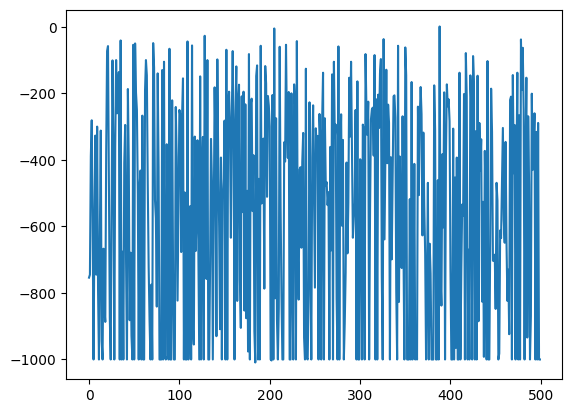

In [15]:
# Initialize environment and agent
environment = GridWorld()
random_agent = RandomAgent()

reward_per_episode = play(environment, random_agent, trials=500)

# Simple learning curve
plt.plot(reward_per_episode)

## Q-Agent

- Here the Q-Learning agent is ran for 500 trials again
- Performance is plotted
- Performance increases greatly

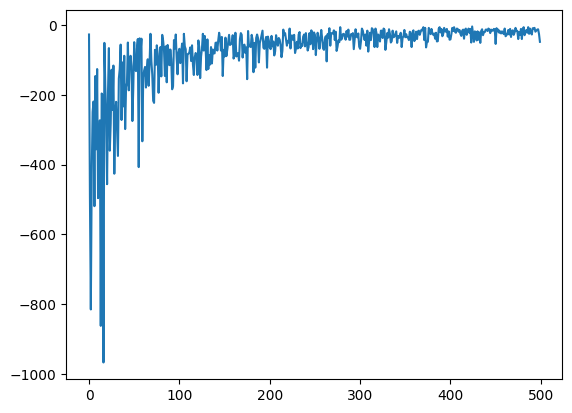

In [16]:
environment = GridWorld()
agentQ = Q_Agent(environment)

# Note the learn=True argument!
reward_per_episode = play(environment, agentQ, trials=500, learn=True)

# Simple learning curve
plt.plot(reward_per_episode)

Print the final Q-value table with nice formatting.

In [17]:
def pretty(d, indent=0):
    for key, value in d.items():
        print('\t' * indent + str(key))
        if isinstance(value, dict):
            pretty(value, indent+1)
        else:
            print('\t' * (indent+1) + str(value))


pretty(agentQ.q_table)

(0, 0)
	UP
		-1.6911736900000003
	DOWN
		-1.66616963923061
	LEFT
		-1.7000000000000002
	RIGHT
		-1.7349448420149267
(0, 1)
	UP
		-1.4
	DOWN
		-1.4819251154805404
	LEFT
		-1.4343573079175131
	RIGHT
		-1.0343814972112977
(0, 2)
	UP
		-0.9908252089999999
	DOWN
		-1.0266922212302
	LEFT
		-1.07137728845373
	RIGHT
		1.4149049167092689
(0, 3)
	UP
		-0.36103502515061237
	DOWN
		-0.6621565654444307
	LEFT
		-0.6477014151000001
	RIGHT
		4.528565867603711
(0, 4)
	UP
		-0.30000000000000004
	DOWN
		-0.30190000000000006
	LEFT
		-0.3271
	RIGHT
		7.075187647189347
(0, 5)
	UP
		-0.1
	DOWN
		-0.07229514590706403
	LEFT
		-0.16627539228316998
	RIGHT
		8.848921410383005
(0, 6)
	UP
		1.7053616022864952
	DOWN
		2.6996776054289104
	LEFT
		0.7856336875465345
	RIGHT
		9.999999999871259
(0, 7)
	UP
		0
	DOWN
		0
	LEFT
		0
	RIGHT
		0
(0, 8)
	UP
		0.8053616023134119
	DOWN
		2.7502113123962593
	LEFT
		9.999999999967276
	RIGHT
		2.550084723330712
(0, 9)
	UP
		-0.2
	DOWN
		-0.2
	LEFT
		8.753346937727184
	RIGHT
		-0.1
(

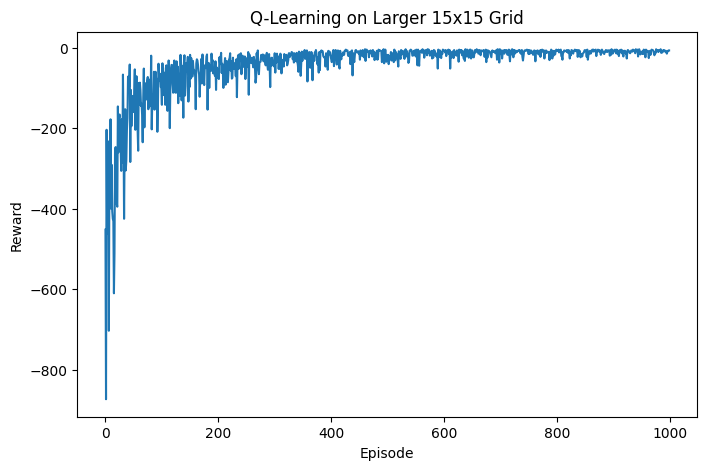

In [18]:
# ============================================================
# LARGE GRIDWORLD EXPERIMENT - 15x15
# ============================================================

# Create the larger GridWorld environment
environment_large = GridWorld()

# Create a new Q-Learning agent for the larger environment
agentQ_large = Q_Agent(environment_large)

# Train the agent for more episodes because
# the larger grid has more states to explore
reward_per_episode_large = play(
    environment_large,
    agentQ_large,
    trials=1000,
    learn=True
)

# Plot the learning curve
plt.figure(figsize=(8, 5))
plt.plot(reward_per_episode_large)

plt.title("Q-Learning on Larger 15x15 Grid")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.show()

### Observation – Larger GridWorld

- Increasing the grid size increases the number of possible states.
- Therefore, the Q-Learning agent has a larger environment to explore.
- The larger grid generally requires more episodes to reach stable performance.
- Execution time also increases because the agent must learn more state-action values.
- Compared with the original 8×8 grid, convergence is expected to be slower in the 15×15 grid.

Training epsilon = 0.1
Training epsilon = 0.5
Training epsilon = 0.9


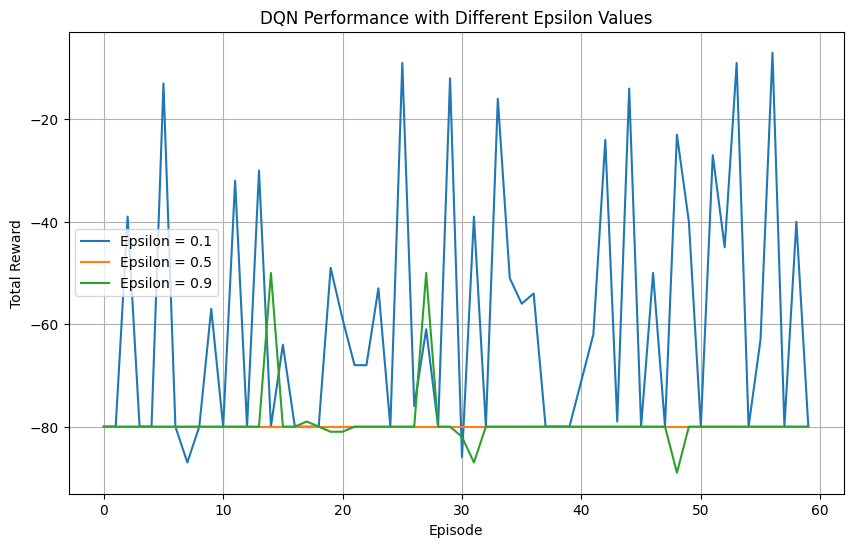

In [20]:
# ============================================================
# QUESTION 3 - FASTER DQN IMPLEMENTATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Convert (row, col) into normalized input
def state_to_input(state, height, width):
    return np.array([
        state[0] / (height - 1),
        state[1] / (width - 1)
    ], dtype=np.float32)

# Build simple neural network
def build_dqn():
    model = Sequential([
        tf.keras.Input(shape=(2,)),
        Dense(16, activation='relu'),
        Dense(16, activation='relu'),
        Dense(4, activation='linear')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='mse'
    )

    return model

# Train DQN
def train_dqn_fast(epsilon, episodes=60):

    env = GridWorld()
    model = build_dqn()

    gamma = 0.95
    action_names = ['UP', 'DOWN', 'LEFT', 'RIGHT']
    rewards = []

    for episode in range(episodes):

        env.__init__()
        total_reward = 0

        for step in range(80):

            old_state = env.current_location

            state_input = state_to_input(
                old_state,
                env.height,
                env.width
            ).reshape(1, 2)

            # Get current Q-values
            q_values = model(state_input, training=False).numpy()[0]

            # Epsilon-greedy
            if np.random.rand() < epsilon:
                action_index = np.random.randint(4)
            else:
                action_index = np.argmax(q_values)

            action = action_names[action_index]

            # Take action
            reward = env.make_step(action)

            new_state = env.current_location

            new_state_input = state_to_input(
                new_state,
                env.height,
                env.width
            ).reshape(1, 2)

            # Next Q-values
            next_q = model(
                new_state_input,
                training=False
            ).numpy()[0]

            # Target
            target_q = q_values.copy()

            if env.check_state() == 'TERMINAL':
                target_q[action_index] = reward
            else:
                target_q[action_index] = (
                    reward + gamma * np.max(next_q)
                )

            # Train one step
            model.train_on_batch(
                state_input,
                target_q.reshape(1, 4)
            )

            total_reward += reward

            if env.check_state() == 'TERMINAL':
                break

        rewards.append(total_reward)

    return rewards


# ============================================================
# TEST EPSILON VALUES
# ============================================================

epsilon_values = [0.1, 0.5, 0.9]

results = {}

for epsilon in epsilon_values:

    print("Training epsilon =", epsilon)

    results[epsilon] = train_dqn_fast(
        epsilon,
        episodes=60
    )


# ============================================================
# PLOT RESULTS
# ============================================================

plt.figure(figsize=(10, 6))

for epsilon in epsilon_values:
    plt.plot(
        results[epsilon],
        label=f"Epsilon = {epsilon}"
    )

plt.title("DQN Performance with Different Epsilon Values")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid()

plt.show()

### Observation – DQN with Different Epsilon Values

The DQN model was tested using epsilon values of 0.1, 0.5 and 0.9.

- Epsilon = 0.1 produced the best overall performance in this experiment.
- With epsilon = 0.1, the agent mostly exploited its learned actions while still performing some exploration.
- Epsilon = 0.5 resulted in more exploration, which reduced the stability of the learned policy.
- Epsilon = 0.9 caused very frequent exploration, so the agent had less opportunity to exploit the learned policy.
- The experiment demonstrates the trade-off between exploration and exploitation in reinforcement learning.
- DQN differs from traditional Q-Learning because a neural network is used to approximate Q-values instead of storing all state-action values in a Q-table.